# Tesla Stock Price Prediction using RNN and LSTM

## Project Objective

The objective of this project is to forecast Tesla stock closing prices using Deep Learning techniques. Both SimpleRNN and LSTM architectures are implemented and compared to determine which model better captures stock price trends. The final solution is deployed through a Streamlit web application.

In [327]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [328]:
import os
print(os.getcwd())

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/notebook


In [329]:
df = pd.read_csv("../TSLA.csv")

## Exploratory Data Analysis

Before training the models, the dataset is examined to understand its structure, identify missing values, and observe historical trends in Tesla stock prices.

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


In [338]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [332]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [333]:
df.duplicated().sum()

0

In [334]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [335]:
df['Date'] = pd.to_datetime(df['Date'])

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.2 KB


In [337]:
df.set_index('Date', inplace=True)

In [324]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


In [ ]:
target = df['Close']

In [ ]:
df[['Close', 'Adj Close']].head()

,Close,Adj Close
Date,,
2010-06-29,23.889999,23.889999
2010-06-30,23.830000,23.830000
2010-07-01,21.959999,21.959999
2010-07-02,19.200001,19.200001
2010-07-06,16.110001,16.110001


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


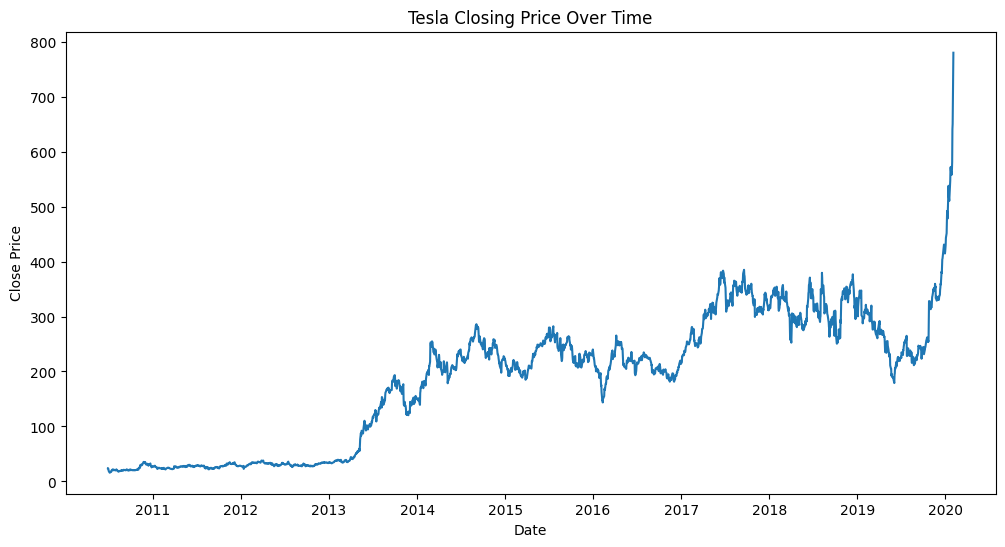

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

### Observation

The historical closing price shows significant growth over time along with periods of volatility. This confirms that Tesla stock prices exhibit strong temporal dependencies, making them suitable for time-series forecasting models such as RNNs and LSTMs.

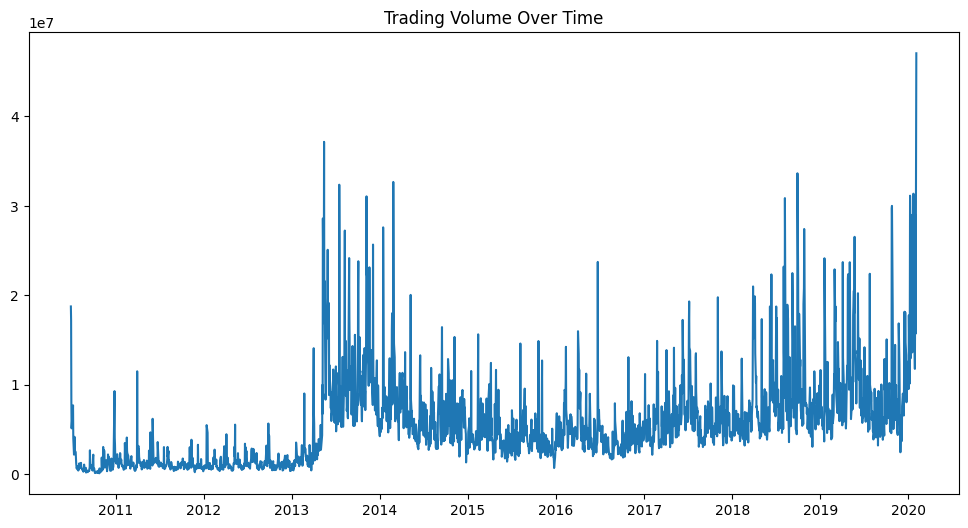

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")

plt.show()

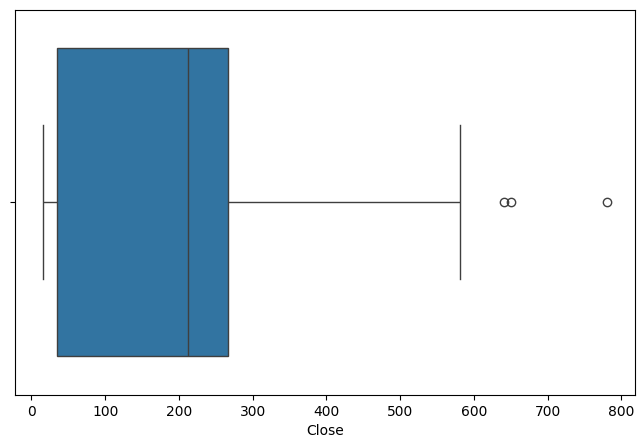

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Close'])

plt.show()

In [ ]:
df['MA20'] = df['Close'].rolling(window=20).mean()

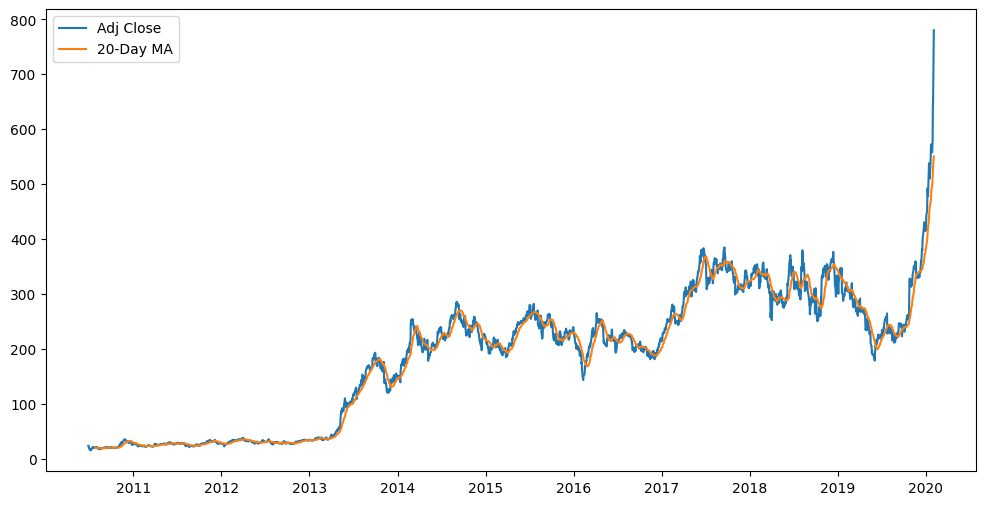

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA20'], label='20-Day MA')

plt.legend()
plt.show()

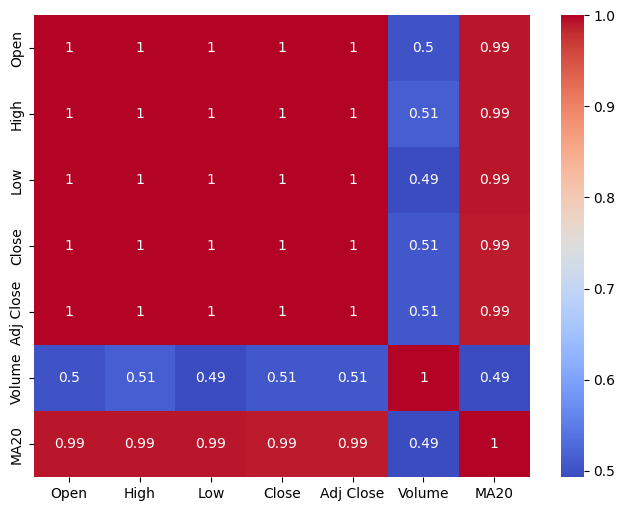

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
data = df[['Close']]

In [ ]:
data.head(10)

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
2010-07-07,15.800000
2010-07-08,17.459999
2010-07-09,17.400000
2010-07-12,17.049999


## Data Preprocessing

Neural networks perform better when input features are normalized. Therefore, MinMax Scaling is applied to transform closing prices into the range [0,1].

In [ ]:


scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [ ]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


In [ ]:
scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [ ]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


## Time Series Window Creation

A lookback window of 60 trading days is used. The model receives the previous 60 days of stock prices as input and learns to predict future stock prices.

In [ ]:
lookback = 60

In [ ]:
def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [ ]:
X, y = create_sequences(scaled_data, lookback)

In [ ]:
print(X.shape)
print(y.shape)

(2356, 60, 1)
(2356, 1)


In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1884, 60, 1)
y_train: (1884, 1)
X_test: (472, 60, 1)
y_test: (472, 1)


In [ ]:
train_data = data[:train_size]
test_data = data[train_size-lookback:]

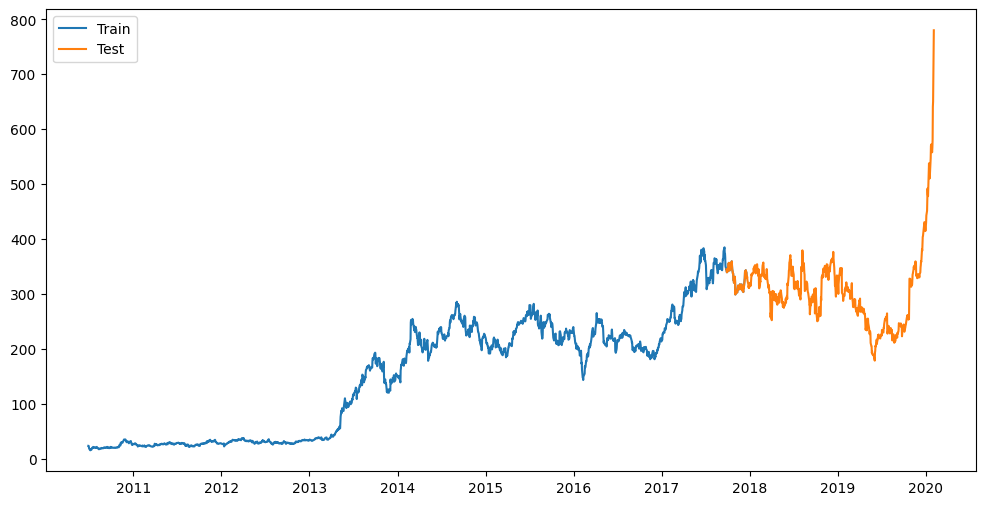

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data, label='Train')
plt.plot(test_data.index, test_data, label='Test')

plt.legend()
plt.show()

In [ ]:
def create_sequences(data, lookback, horizon):

    X = []
    y = []

    for i in range(lookback, len(data)-horizon+1):

        X.append(data[i-lookback:i])

        y.append(data[i+horizon-1])

    return np.array(X), np.array(y)

In [ ]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [ ]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [ ]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

## SimpleRNN Model

A Simple Recurrent Neural Network is implemented as the baseline model. RNNs can capture sequential dependencies but may struggle with long-term memory due to the vanishing gradient problem.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(
    SimpleRNN(
        units=50
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
rnn_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
checkpoint = ModelCheckpoint(
    '../models/best_rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())

2.16.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
rnn_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(1884, 60, 1)
(1884, 1)


In [ ]:
print(X_train.dtype)
print(y_train.dtype)

float64
float64


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0322 - val_loss: 0.0026
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 8.5294e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - val_loss: 8.4008e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - val_loss: 9.4651e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 4.5812e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 5.6864e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - val_loss: 2.4650e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - val_loss: 2.6182e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 2.1478e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 2.1616e-04
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━

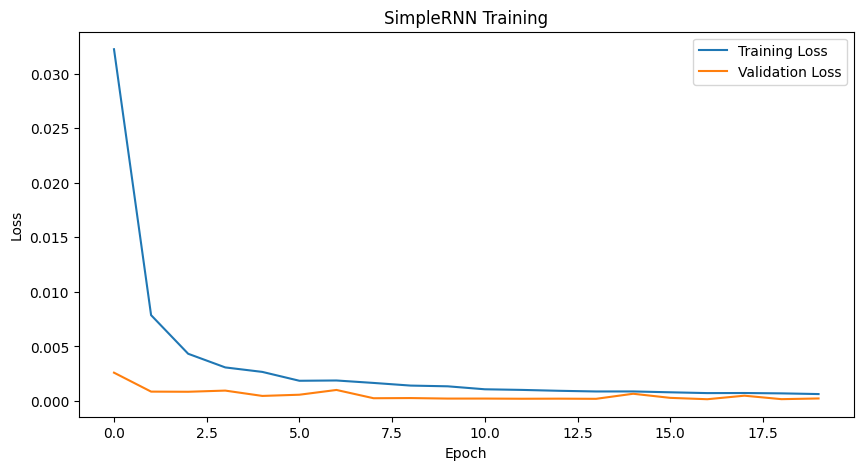

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("SimpleRNN Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

### RNN Training Analysis

The training and validation loss curves indicate how effectively the model learns patterns from the data. Stable convergence suggests successful learning, while divergence would indicate overfitting.

In [ ]:
rnn_predictions = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

actual_prices = scaler.inverse_transform(y_test)

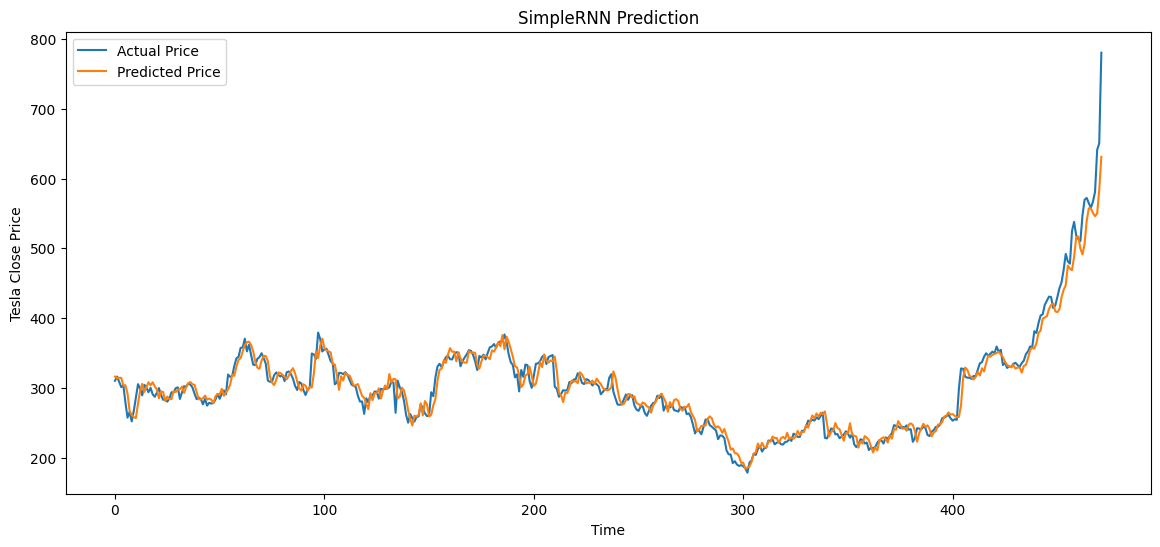

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [ ]:
test_dates = data.index[-len(actual_prices):]

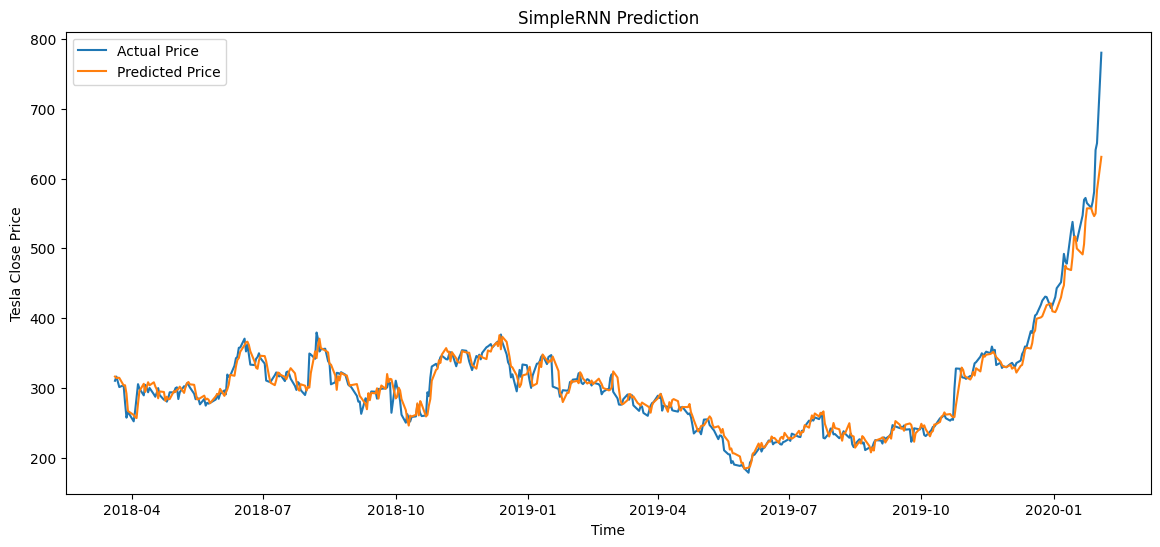

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [ ]:
mse_rnn = mean_squared_error(
    actual_prices,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    actual_prices,
    rnn_predictions
)

r2_rnn = r2_score(
    actual_prices,
    rnn_predictions
)

print("MSE :", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)
print("R2  :", r2_rnn)

MSE : 259.13428776487206
RMSE: 16.097648516627267
MAE : 10.330436673875711
R2  : 0.9508214141996553


In [ ]:
rnn_model.save("../models/simple_rnn_model.keras")

In [ ]:
import os
print(os.listdir("../models"))

['best_lstm_model.keras', 'lstm_model.keras', 'model_1day.keras', 'best_rnn_model.keras', 'model_10day.keras', 'final_lstm_model.keras', 'simple_rnn_model.keras', 'model_5day.keras']


## LSTM Model

Long Short-Term Memory networks are designed to overcome limitations of traditional RNNs. Through memory cells and gating mechanisms, LSTMs can retain important information over longer time periods.

In [ ]:
from tensorflow.keras.layers import LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(
        units=50
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0043 - val_loss: 4.3704e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.9204e-04 - val_loss: 4.3184e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8401e-04 - val_loss: 6.2671e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.0205e-04 - val_loss: 4.7438e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5401e-04 - val_loss: 4.1527e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.8458e-04 - val_loss: 8.6067e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.3904e-04 - val_loss: 4.5664e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.3358e-04 - val_loss: 4.7797e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.1797e-04 - val_loss: 3.6814e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7801e-04 - val_loss: 4.2026e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7980e-04 - 

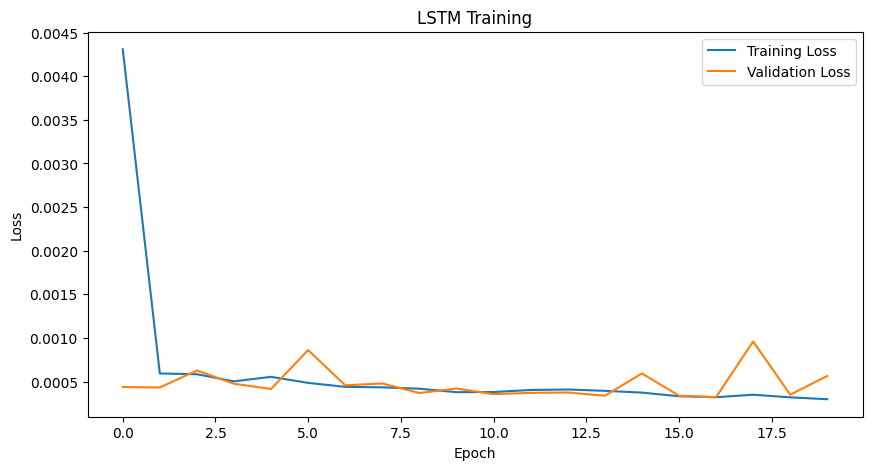

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

### LSTM Training Analysis

Compared to the SimpleRNN model, the LSTM demonstrates improved convergence and stronger capability to capture long-term dependencies in stock price movements.

In [ ]:
lstm_predictions = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

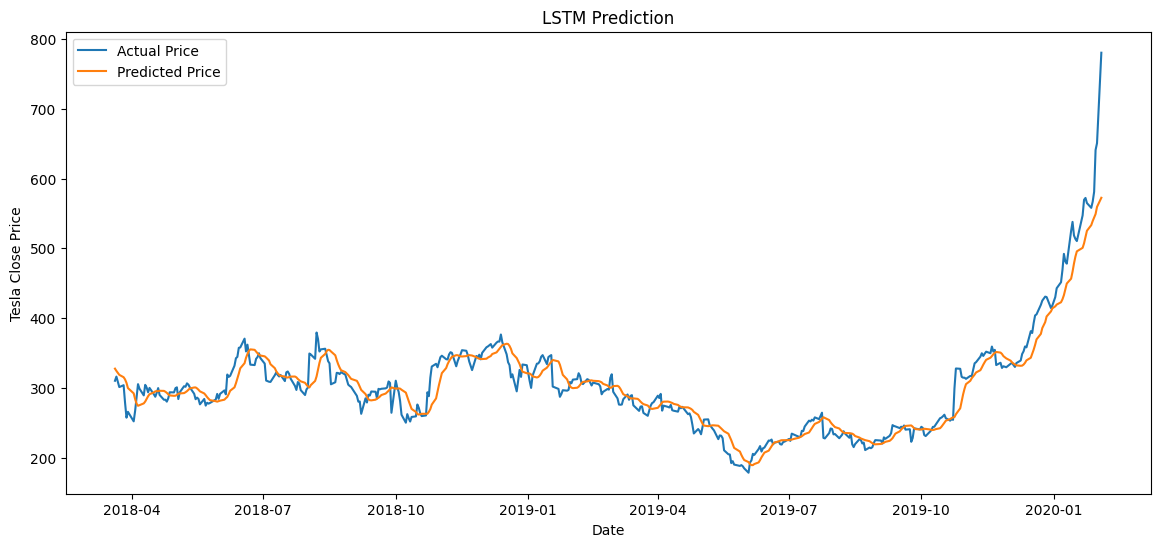

In [ ]:
test_dates = data.index[-len(actual_prices):]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='Predicted Price'
)

plt.title("LSTM Prediction")

plt.xlabel("Date")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse_lstm = mean_squared_error(
    actual_prices,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

r2_lstm = r2_score(
    actual_prices,
    lstm_predictions
)

print("MSE :", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("R2  :", r2_lstm)

MSE : 505.692318540911
RMSE: 22.487603663816895
MAE : 15.365431414486645
R2  : 0.9040295543656316


In [ ]:
lstm_model.save("../models/lstm_model.keras")

In [ ]:
comparison = pd.DataFrame({
    'Model':['SimpleRNN','LSTM'],
    'MSE':[mse_rnn,mse_lstm],
    'RMSE':[rmse_rnn,rmse_lstm],
    'MAE':[mae_rnn,mae_lstm],
    'R2':[r2_rnn,r2_lstm]
})

comparison

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,259.134288,16.097649,10.330437,0.950821
1,LSTM,505.692319,22.487604,15.365431,0.904030


In [ ]:
comparison.sort_values(
    by='RMSE'
)

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,259.134288,16.097649,10.330437,0.950821
1,LSTM,505.692319,22.487604,15.365431,0.904030


In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_lstm_model(units, dropout_rate, learning_rate):

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(Dropout(dropout_rate))

    model.add(LSTM(units))

    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )

    return model

In [ ]:
units_list = [32, 64]

dropout_list = [0.2, 0.3]

learning_rate_list = [0.001, 0.0001]

In [ ]:
results = []

In [ ]:
for units in units_list:

    for dropout in dropout_list:

        for lr in learning_rate_list:

            print(
                f"Units={units}, "
                f"Dropout={dropout}, "
                f"LR={lr}"
            )

            model = build_lstm_model(
                units,
                dropout,
                lr
            )

            history = model.fit(
                X_train,
                y_train,
                epochs=10,
                batch_size=32,
                validation_split=0.1,
                verbose=0
            )

            best_val_loss = min(
                history.history['val_loss']
            )

            results.append([
                units,
                dropout,
                lr,
                best_val_loss
            ])

Units=32, Dropout=0.2, LR=0.001


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Units=32, Dropout=0.2, LR=0.0001
Units=32, Dropout=0.3, LR=0.001
Units=32, Dropout=0.3, LR=0.0001
Units=64, Dropout=0.2, LR=0.001
Units=64, Dropout=0.2, LR=0.0001
Units=64, Dropout=0.3, LR=0.001
Units=64, Dropout=0.3, LR=0.0001


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Units',
        'Dropout',
        'Learning Rate',
        'Val Loss'
    ]
)

results_df

,Units,Dropout,Learning Rate,Val Loss
0,32,0.2,0.0010,0.000418
1,32,0.2,0.0001,0.000630
2,32,0.3,0.0010,0.000416
3,32,0.3,0.0001,0.000605
4,64,0.2,0.0010,0.000386
5,64,0.2,0.0001,0.000557
6,64,0.3,0.0010,0.000411
7,64,0.3,0.0001,0.000530


In [ ]:
results_df.sort_values(
    by='Val Loss'
)

,Units,Dropout,Learning Rate,Val Loss
4,64,0.2,0.0010,0.000386
6,64,0.3,0.0010,0.000411
2,32,0.3,0.0010,0.000416
0,32,0.2,0.0010,0.000418
7,64,0.3,0.0001,0.000530
5,64,0.2,0.0001,0.000557
3,32,0.3,0.0001,0.000605
1,32,0.2,0.0001,0.000630


In [ ]:
best_row = results_df.sort_values(
    by='Val Loss'
).iloc[0]

best_row

Units            64.000000
Dropout           0.200000
Learning Rate     0.001000
Val Loss          0.000386
Name: 4, dtype: float64

In [ ]:
final_lstm = build_lstm_model(
    units=int(best_row['Units']),
    dropout_rate=float(best_row['Dropout']),
    learning_rate=float(best_row['Learning Rate'])
)

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_final = final_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0051 - val_loss: 7.0773e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.2277e-04 - val_loss: 4.4724e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.8205e-04 - val_loss: 4.3399e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.8270e-04 - val_loss: 4.1898e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8190e-04 - val_loss: 5.6012e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.5773e-04 - val_loss: 7.5362e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.4143e-04 - val_loss: 4.1874e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.3879e-04 - val_loss: 0.0010
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.7238e-04 - val_loss: 3.7632e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.5067e-04 - val_loss: 6.0821e-04


In [ ]:
final_predictions = final_lstm.predict(X_test)

final_predictions = scaler.inverse_transform(
    final_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
mse_final = mean_squared_error(
    actual_prices,
    final_predictions
)

rmse_final = np.sqrt(mse_final)

mae_final = mean_absolute_error(
    actual_prices,
    final_predictions
)

r2_final = r2_score(
    actual_prices,
    final_predictions
)

print("RMSE:", rmse_final)
print("MAE :", mae_final)
print("R2  :", r2_final)

RMSE: 32.8509029537097
MAE : 23.138872914573543
R2  : 0.7951925373268353


In [ ]:
final_lstm.save(
    "../models/final_lstm_model.keras"
)

In [ ]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [ ]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [ ]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

## Model Performance Comparison

Both models are evaluated using RMSE and visual comparison of predicted versus actual stock prices.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_predictions))
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))

print("RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

RNN RMSE: 307.96589415325207
LSTM RMSE: 305.29224820676234


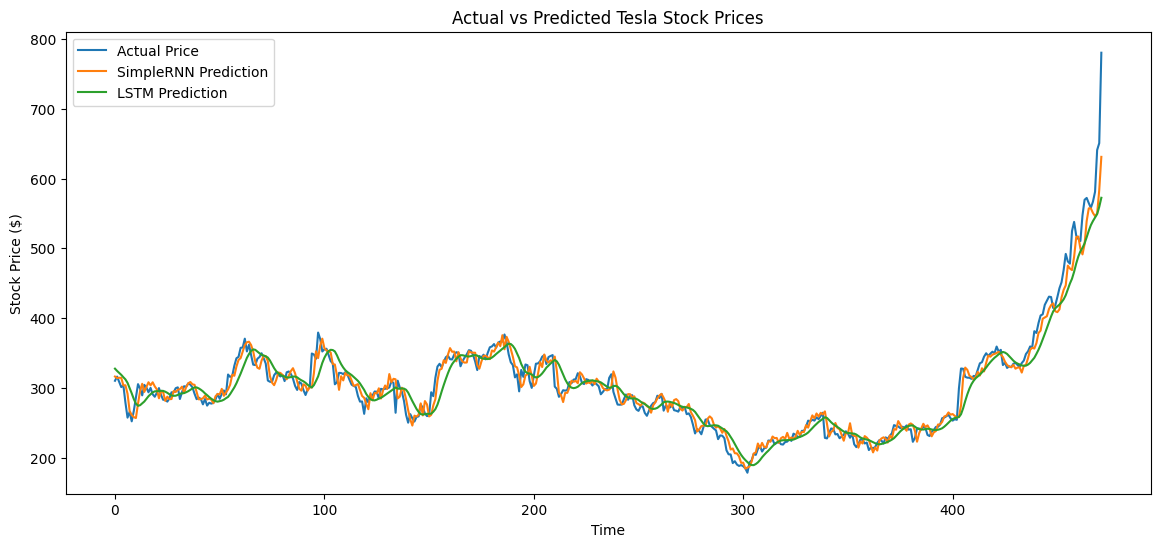

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    rnn_predictions,
    label="SimpleRNN Prediction"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.title("Actual vs Predicted Tesla Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price ($)")
plt.legend()

plt.show()

### Performance Analysis

The LSTM model follows the actual stock price trend more closely than the SimpleRNN model. Lower prediction errors and smoother tracking of market movements indicate superior forecasting capability.

Based on these results, the LSTM architecture is selected for deployment.

## Multi-Horizon Forecasting

To evaluate forecasting performance across different time horizons, separate LSTM models are trained for:

- 1-Day Ahead Prediction
- 5-Day Ahead Prediction
- 10-Day Ahead Prediction

This allows analysis of how prediction accuracy changes as the forecast horizon increases.

In [ ]:
def split_data(X, y):

    train_size = int(len(X)*0.8)

    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]

    return X_train, X_test, y_train, y_test

In [ ]:
X1_train, X1_test, y1_train, y1_test = split_data(X1, y1)

X5_train, X5_test, y5_train, y5_test = split_data(X5, y5)

X10_train, X10_test, y10_train, y10_test = split_data(X10, y10)

In [ ]:
def build_final_model():

    model = Sequential()

    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(64))

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(0.001),
        loss='mean_squared_error'
    )

    return model

In [ ]:
model_1day = build_final_model()

model_1day.fit(
    X1_train,
    y1_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0025 - val_loss: 6.0103e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.3359e-04 - val_loss: 6.9681e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.0578e-04 - val_loss: 5.5657e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.3615e-04 - val_loss: 4.7516e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.0286e-04 - val_loss: 4.7862e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.4392e-04 - val_loss: 8.8141e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4281e-04 - val_loss: 6.3443e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7586e-04 - val_loss: 4.3840e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.3559e-04 - val_loss: 5.3566e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.6835e-04 - val_loss: 9.3469e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7045e-04 - val_loss: 3

In [ ]:
model_1day.save(
    "../models/model_1day.keras"
)

In [ ]:
pred1 = model_1day.predict(X1_test)

pred1 = scaler.inverse_transform(pred1)

actual1 = scaler.inverse_transform(y1_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
rmse_1 = np.sqrt(
    mean_squared_error(
        actual1,
        pred1
    )
)

print(rmse_1)

21.66170654635449


In [ ]:
model_5day = build_final_model()

model_5day.fit(
    X5_train,
    y5_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0041 - val_loss: 6.9371e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0110e-04 - val_loss: 8.5976e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.6353e-04 - val_loss: 7.9586e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.9383e-04 - val_loss: 8.2068e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.0792e-04 - val_loss: 0.0011
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.6817e-04 - val_loss: 6.5687e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5128e-04 - val_loss: 7.2946e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.0346e-04 - val_loss: 9.5263e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.1229e-04 - val_loss: 6.8654e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8896e-04 - val_loss: 0.0015
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.7043e-04 - val_loss: 9.9935e-0

In [ ]:
model_5day.save(
    "../models/model_5day.keras"
)

In [ ]:
pred5 = model_5day.predict(X5_test)

pred5 = scaler.inverse_transform(pred5)

actual5 = scaler.inverse_transform(y5_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
rmse_5 = np.sqrt(
    mean_squared_error(
        actual5,
        pred5
    )
)

print(rmse_5)

31.702252995425244


In [ ]:
model_10day = build_final_model()

model_10day.fit(
    X10_train,
    y10_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0034 - val_loss: 8.2870e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.2198e-04 - val_loss: 8.3771e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8503e-04 - val_loss: 9.9912e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5651e-04 - val_loss: 8.4281e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4943e-04 - val_loss: 0.0015
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9174e-04 - val_loss: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8047e-04 - val_loss: 0.0015
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.4601e-04 - val_loss: 8.5141e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.4533e-04 - val_loss: 9.4827e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.2109e-04 - val_loss: 9.4639e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.9065e-04 - val_loss: 8.8864e-04
Ep

In [ ]:
model_10day.save(
    "../models/model_10day.keras"
)

In [ ]:
pred10 = model_10day.predict(X10_test)

pred10 = scaler.inverse_transform(pred10)

actual10 = scaler.inverse_transform(y10_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
rmse_10 = np.sqrt(
    mean_squared_error(
        actual10,
        pred10
    )
)

print(rmse_10)

44.493084711626665


In [ ]:
forecast_results = pd.DataFrame({

    'Forecast Horizon': [
        '1 Day',
        '5 Days',
        '10 Days'
    ],

    'RMSE': [
        rmse_1,
        rmse_5,
        rmse_10
    ]
})

forecast_results

,Forecast Horizon,RMSE
0,1 Day,21.661707
1,5 Days,31.702253
2,10 Days,44.493085


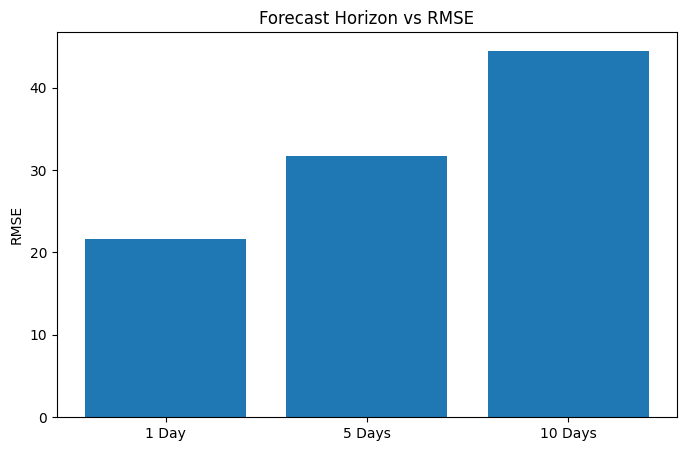

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    forecast_results['Forecast Horizon'],
    forecast_results['RMSE']
)

plt.title(
    'Forecast Horizon vs RMSE'
)

plt.ylabel('RMSE')

plt.show()

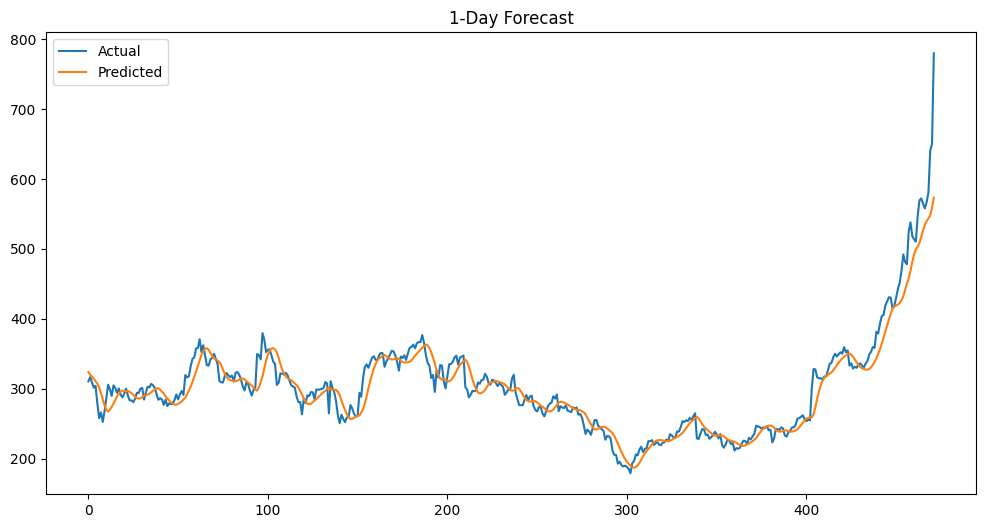

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual1, label='Actual')
plt.plot(pred1, label='Predicted')

plt.title('1-Day Forecast')

plt.legend()

plt.show()

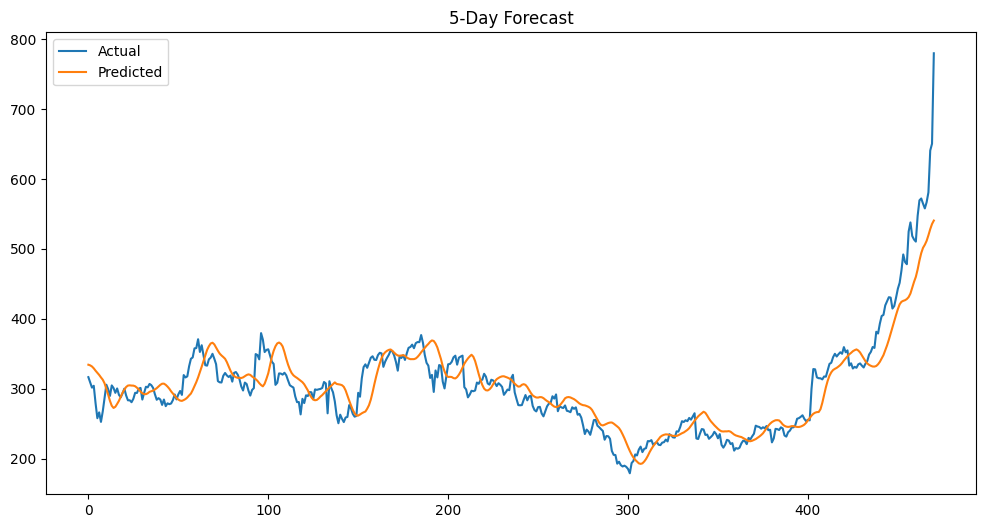

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual5, label='Actual')
plt.plot(pred5, label='Predicted')

plt.title('5-Day Forecast')

plt.legend()

plt.show()

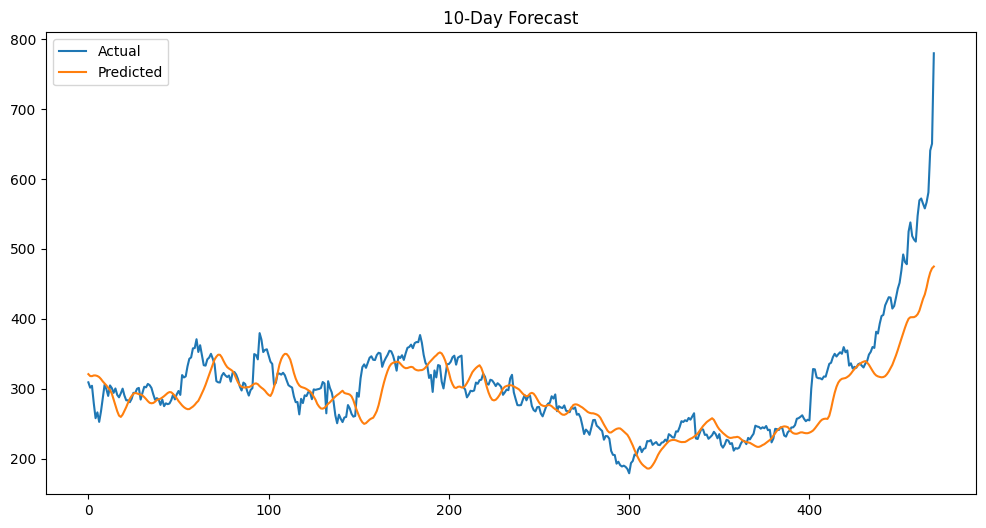

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual10, label='Actual')
plt.plot(pred10, label='Predicted')

plt.title('10-Day Forecast')

plt.legend()

plt.show()

# Conclusion

This project successfully demonstrates the application of Deep Learning to stock market forecasting.

Key findings:

- Both SimpleRNN and LSTM models were capable of learning stock price patterns.
- LSTM achieved superior performance due to its ability to capture long-term dependencies.
- Prediction accuracy decreases as forecasting horizons increase.
- Historical closing prices alone provide useful predictive information but cannot fully capture market dynamics.

Future improvements may include:
- Technical indicators (RSI, MACD, EMA)
- Trading volume analysis
- News sentiment analysis
- Macroeconomic indicators
- Transformer-based forecasting models